In [1]:
from pathlib import Path

from maite_datasets.object_detection import MILCO

from dataeval_flow import run_tasks, set_device
from dataeval_flow.config import (
    CocoDatasetConfig,
    MetadataPolicyConfig,
    PipelineConfig,
    PreprocessingStep,
    PreprocessorConfig,
    SourceConfig,
    TaskConfig,
)
from dataeval_flow.config.extractors import BoVWExtractorConfig
from dataeval_flow.evaluators.shift import ChunkedDriftConfig, DriftKNeighborsConfig
from dataeval_flow.workflows.quality import QualityConfig
from dataeval_flow.workflows.shift import ShiftConfig

data_root = Path("./data")

# `base` fetches the archive once; the two calls below export each split for datamaite.
MILCO(root=data_root, image_set="base", download=True)
MILCO(root=data_root, image_set="train", as_datamaite=True)
MILCO(root=data_root, image_set="operational", as_datamaite=True)

/builds/jatic/aria/dataeval-flow/.nox/docs/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/builds/jatic/aria/dataeval-flow/.nox/docs/lib/python3.11/site-packages/torch/jit/_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


ObjectDetectionDataset(samples=(ImageObjectDetectionSample(image_id=1, path_or_uri='data/milco_datamaite_operational/0001_2010.jpg', image_bytes=None, file_name='0001_2010.jpg', width=416, height=416, split=None, metadata={'year': '2010', 'original_id': '0001_2010', 'original_split': 'operational'}, region=None, detections=()), ImageObjectDetectionSample(image_id=2, path_or_uri='data/milco_datamaite_operational/0002_2010.jpg', image_bytes=None, file_name='0002_2010.jpg', width=1024, height=1024, split=None, metadata={'year': '2010', 'original_id': '0002_2010', 'original_split': 'operational'}, region=None, detections=()), ImageObjectDetectionSample(image_id=3, path_or_uri='data/milco_datamaite_operational/0003_2010.jpg', image_bytes=None, file_name='0003_2010.jpg', width=416, height=416, split=None, metadata={'year': '2010', 'original_id': '0003_2010', 'original_split': 'operational'}, region=None, detections=()), ImageObjectDetectionSample(image_id=4, path_or_uri='data/milco_datamaite

In [2]:
set_device("cpu")  # the same numbers on a machine with a GPU

config = PipelineConfig(
    max_processes=2,
    seed=0,
    # `original_id` numbers each frame, so it names the frames rather than describing them.
    metadata=[MetadataPolicyConfig(name="milco", exclude=["original_id"])],
    datasets=[
        CocoDatasetConfig(name="reference", path=str(data_root / "milco_datamaite_train")),
        CocoDatasetConfig(name="operational", path=str(data_root / "milco_datamaite_operational")),
    ],
    sources=[
        SourceConfig(name="ref-src", dataset="reference"),
        SourceConfig(name="ops-src", dataset="operational"),
    ],
    # BoVW reads SIFT keypoints, so every frame is resized to one size first.
    preprocessors=[
        PreprocessorConfig(
            name="sonar",
            steps=[PreprocessingStep(step="Resize", params={"size": [256, 256], "antialias": True})],
        )
    ],
    extractors=[BoVWExtractorConfig(name="bovw", vocab_size=256, batch_size=32, preprocessor="sonar")],
    workflows=[
        QualityConfig(
            name="clean", outliers={"flags": ["pixel", "visual"], "outlier_threshold": "zscore"}, metadata="milco"
        ),
        ShiftConfig(
            name="drift",
            detectors=[
                DriftKNeighborsConfig(
                    k=10, chunking=ChunkedDriftConfig(chunk_size=50, incomplete="append", threshold=("zscore", 4.0))
                ),
            ],
        ),
    ],
    tasks=[
        TaskConfig(name="clean-reference", workflow="clean", sources="ref-src", extractor="bovw"),
        TaskConfig(name="drift-operational", workflow="drift", sources=["ref-src", "ops-src"], extractor="bovw"),
    ],
)

In [3]:
results = run_tasks(config, cache_dir=Path("./cache"))
clean, drift = results["clean-reference"], results["drift-operational"]

/builds/jatic/aria/dataeval-flow/src/dataeval_flow/_classwise.py:37: UserWarning: `original_id` was binned automatically ('uniform_width') because no bins were declared. The bin count is derived from the data, so it is not stable across samples and the same factor measured twice may not be comparable. Declare cutoffs with continuous_factor_bins={"original_id": [...]} to control this.
  td = metadata.rows_at(metadata.label_level).select("item_index", "target_index", "class_label")


In [4]:
assert all(r.success for r in results.values()), [r.errors for r in results.values() if not r.success]

In [5]:
# The page styles its whole document, so the docs show it in an iframe of its own rather than
# letting its stylesheet restyle this site. Readers don't need this to use `to_html()`.
import html

from IPython.display import display


def show(page: str, height: int = 720) -> None:
    """*page* in an iframe, so its stylesheet and script stay inside it."""
    frame = (
        f'<iframe srcdoc="{html.escape(page, quote=True)}" title="HTML report" loading="lazy" '
        f'style="width:100%;height:{height}px;border:1px solid #d1d9e0;border-radius:6px"></iframe>'
    )
    display({"text/html": frame}, raw=True)

In [6]:
print(clean.report())


  QUALITY
  Workflow:     clean (quality)
  Timestamp:    2026-10-09T07:28:04.384716+00:00
  Duration:     0.43s
  Source:       ref-src (reference)
  Model:        bovw (bovw)
  Preprocessor: sonar

  Steps: 9 ran

  SUMMARY
  Image Outliers ...................................... 11 images (4.2%)  [!!]
  Target Outliers .................................... 32 targets (6.5%)  [!!]
  Class Outliers ............ worst: NOMBO (7.5%), 2/2 classes over 3.0%  [!!]
  Image Duplicates .................... 0 exact (0.0%), 150 near (57.5%)  [!!]

  Health: 4 warning(s) [!!] — review flagged findings

  IMAGE OUTLIERS                                                11 images (4.2%)
  From Outliers
    Item  Flags  Flagged by
    ----  -----  ----------------------
    91        7  contrast 4.811 > 4.444
                 darkness 10 < 22.41
                 entropy 2.519 < 2.868
                 mean 10.85 < 19.32
                 std 24.48 < 25.62
                 var 599.1 < 647
                

In [7]:
output_dir = Path("./output/html_reports")
output_dir.mkdir(parents=True, exist_ok=True)

for name, result in results.items():
    page = output_dir / f"{name}.html"
    page.write_text(result.to_html(), encoding="utf-8")
    print(f"{page}  ({page.stat().st_size:,} bytes)")

output/html_reports/clean-reference.html  (1,545,608 bytes)
output/html_reports/drift-operational.html  (26,301 bytes)


<iframe srcdoc="<!doctype html>
<html lang="en">
<head>
<meta charset="utf-8">
<meta name="viewport" content="width=device-width, initial-scale=1">
<title>Quality — clean</title>
<style>:root { color-scheme: light dark;
 --bg: #ffffff; --card: #ffffff; --soft: #f6f8fa; --ink: #111827; --muted: #6b7280; --rule: #e5e7eb;
 --link: #1d4ed8; --ok: #16a34a; --info: #2563eb; --warning: #d97706; --mark: #dc2626;
 --s0: #2563eb; --s1: #d97706; --s2: #7c3aed; --s3: #16a34a;
 --tag: #eef2ff; --tag-ink: #1e1b4b;
}
@media (prefers-color-scheme: dark) { :root {
 --bg: #0f1115; --card: #171a21; --soft: #1d212a; --ink: #e5e7eb; --muted: #9ca3af; --rule: #2a2f3a;
 --link: #93c5fd; --ok: #22c55e; --info: #60a5fa; --warning: #f59e0b; --mark: #f87171;
 --s0: #60a5fa; --s1: #f59e0b; --s2: #a78bfa; --s3: #22c55e;
 --tag: #232a3d; --tag-ink: #c7d2fe;
} }
body { margin: 0; color: var(--ink); background: var(--bg);
 font: 15px/1.5 system-ui, -apple-system, "Segoe UI", Roboto, "Helvetica Neue", Arial, sans-serif; }
main { max-width: 72rem; margin: 0 auto; padding: 1.5rem; }
a { color: var(--link); }
h1, h2, h3, h4 { margin: 1.25rem 0 0.5rem; line-height: 1.25; }
h1 { font-size: 1.6rem; } h2 { font-size: 1.2rem; } h3 { font-size: 1.05rem; } h4 { font-size: 0.95rem; }
nav.contents { border: 1px solid var(--rule); border-radius: 7px; padding: 0.25rem 1rem; margin-bottom: 1.5rem; }
nav.contents h2 { font-size: 1rem; margin: 0.5rem 0; }
.controls { display: flex; justify-content: flex-end; gap: 0.5rem; margin-bottom: 0.5rem; }
.controls button { font: inherit; font-size: 0.8rem; padding: 0.2rem 0.7rem; cursor: pointer;
 color: var(--ink); background: var(--soft); border: 1px solid var(--rule); border-radius: 4px; }
.report { margin-bottom: 2.5rem; }
.report-head { display: flex; align-items: baseline; gap: 0.75rem; flex-wrap: wrap;
 border-bottom: 2px solid var(--ink); padding-bottom: 0.3rem; }
.report-head h1 { margin: 0; }
dl.fields.provenance { display: grid; grid-template-columns: max-content 1fr; gap: 0.15rem 1rem;
 margin: 0.6rem 0 1.2rem; padding: 0.5rem 0.8rem; background: var(--soft); border-radius: 6px;
 color: var(--muted); font-size: 0.85rem; }
dl.provenance dt { font-weight: 600; color: var(--ink); }
dl.provenance dd { margin: 0; overflow-wrap: anywhere; }
section.section > h2 { border-bottom: 1px solid var(--rule); padding-bottom: 0.2rem; }
details.card, details.panel { background: var(--card); border: 1px solid var(--rule);
 border-left: 4px solid var(--info); border-radius: 7px; padding: 0.3rem 1rem 0.6rem; margin: 0.9rem 0; }
details.card.ok { border-left-color: var(--ok); } details.card.warning { border-left-color: var(--warning); }
details.panel { border-left-color: var(--rule); margin-top: 1.5rem; }
:is(details.card, details.panel) > summary { cursor: pointer; list-style: none; }
:is(details.card, details.panel) > summary::-webkit-details-marker { display: none; }
:is(details.card, details.panel) > summary h2 { display: inline; font-size: 1.1rem; margin: 0; }
:is(details.card, details.panel) > summary::before { content: "▸"; color: var(--muted); margin-right: 0.4rem; }
:is(details.card, details.panel)[open] > summary::before { content: "▾"; }
.brief { font-weight: normal; color: var(--muted); margin-left: 0.5rem; }
.badge { font-size: 0.72rem; font-weight: 700; letter-spacing: 0.02em; border-radius: 1rem; padding: 0.05rem 0.55rem;
 margin-left: 0.5rem; color: #fff; background: var(--info); vertical-align: middle; }
.badge.ok { background: var(--ok); } .badge.warning { background: var(--warning); }
.badge.failed { background: var(--mark); }
code, pre { font-family: ui-monospace, SFMono-Regular, Menlo, Consolas, "DejaVu Sans Mono", monospace; }
code { font-size: 0.9em; background: var(--soft); padding: 0 0.2em; border-radius: 3px; }
pre { background: var(--soft); padding: 0.75rem; overflow-x: auto; font-size: 0.85rem; }
pre code { background: none; padding: 0; }
table { border-collapse: collapse; margin: 0.5rem 0; font-size: 0.85rem; font-
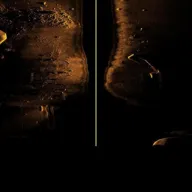
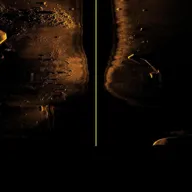
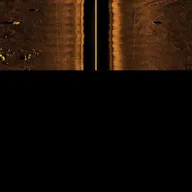
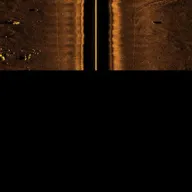
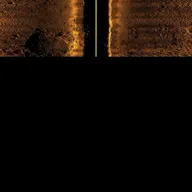
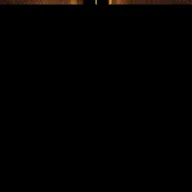
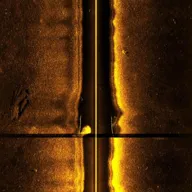
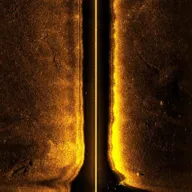
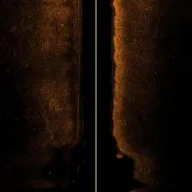
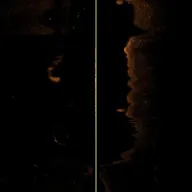
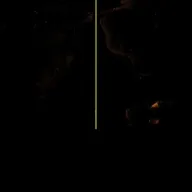
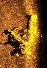
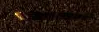
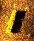
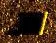
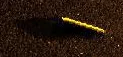
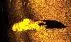
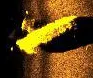
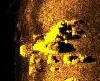
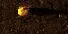
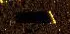
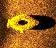
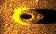
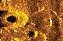
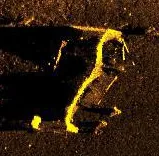
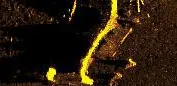
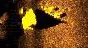
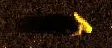
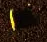
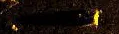
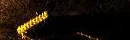
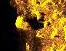
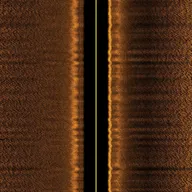
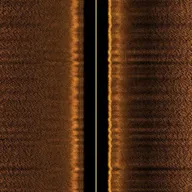
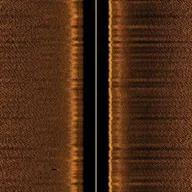
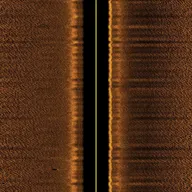
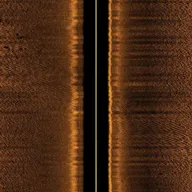
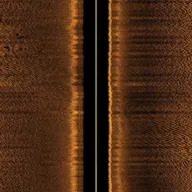
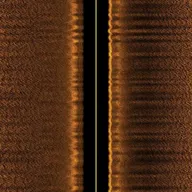
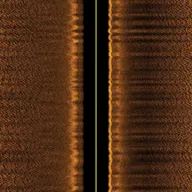
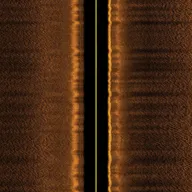
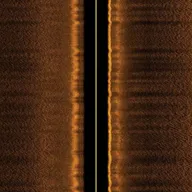
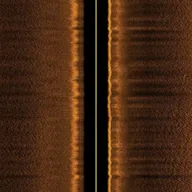
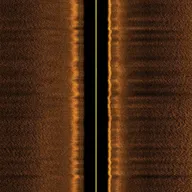
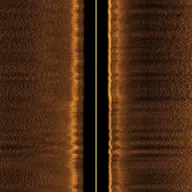
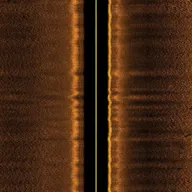
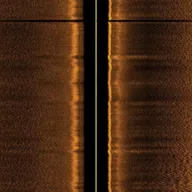
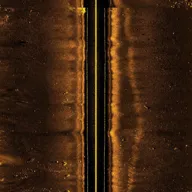
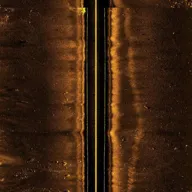
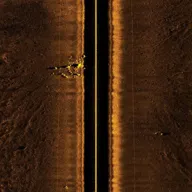
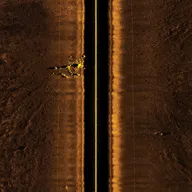
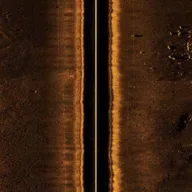
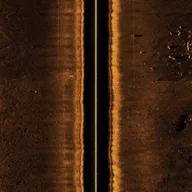
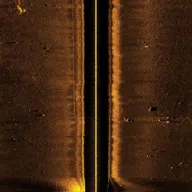
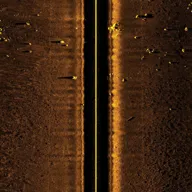
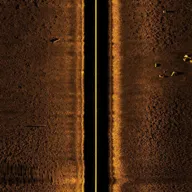
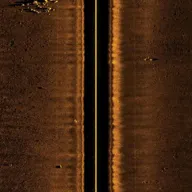
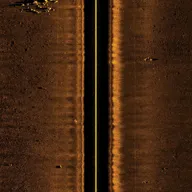
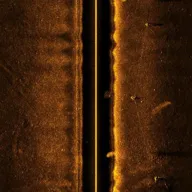
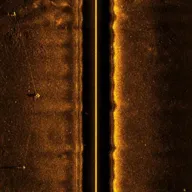
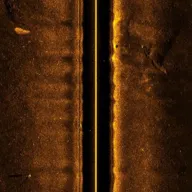
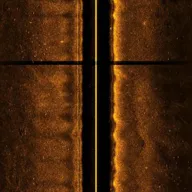
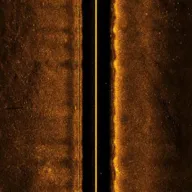
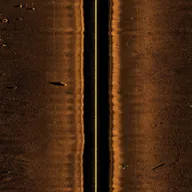
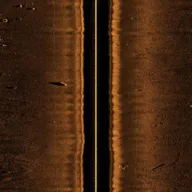
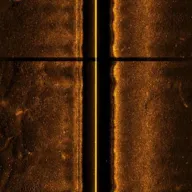
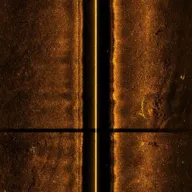
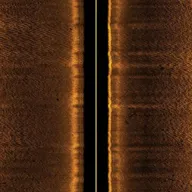
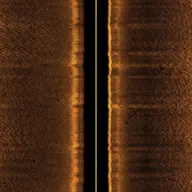
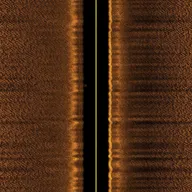
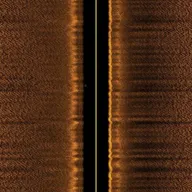
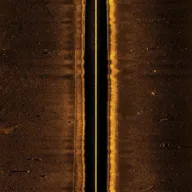
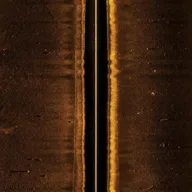
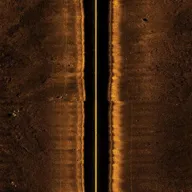
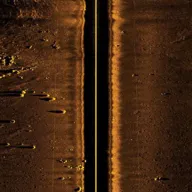
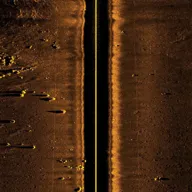
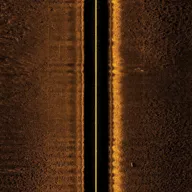
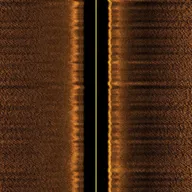
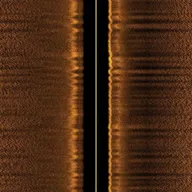
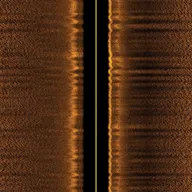
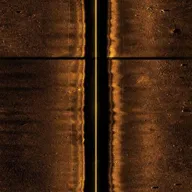
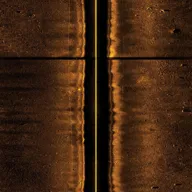
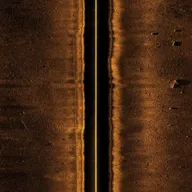
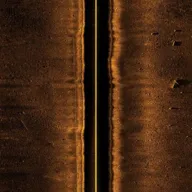
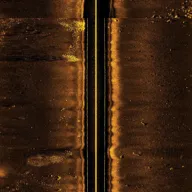
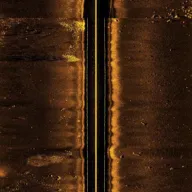
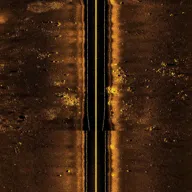
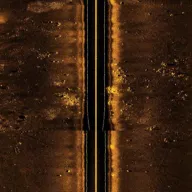
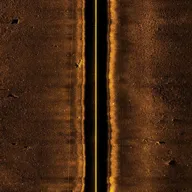
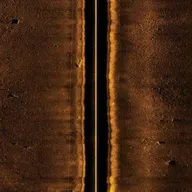
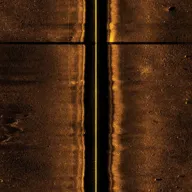
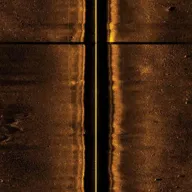
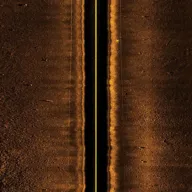
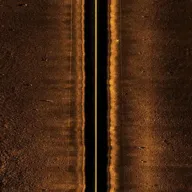
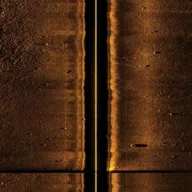
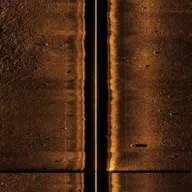
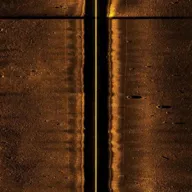
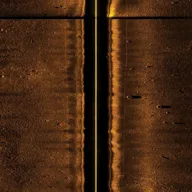
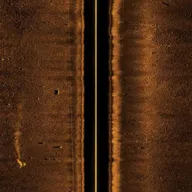
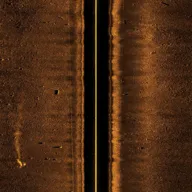
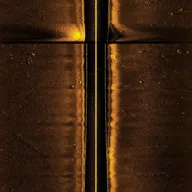
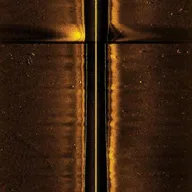
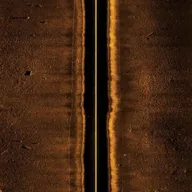
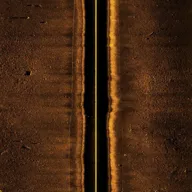
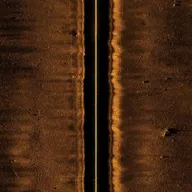
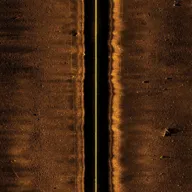
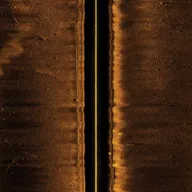
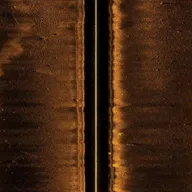
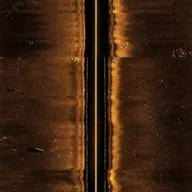
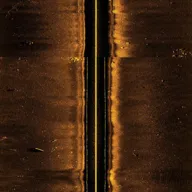
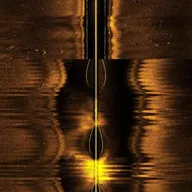
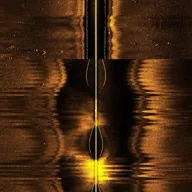
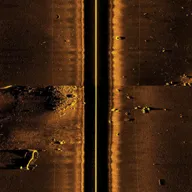
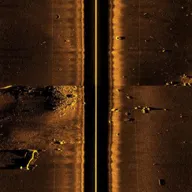
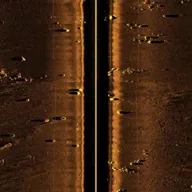
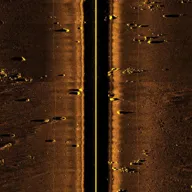
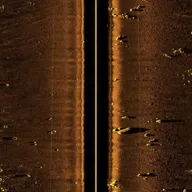
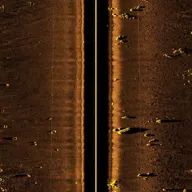
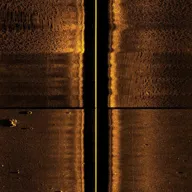
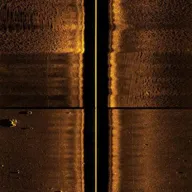
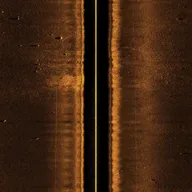
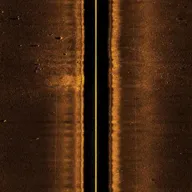
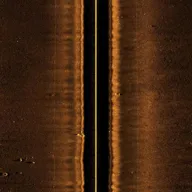
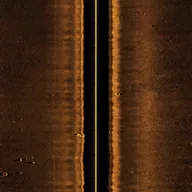
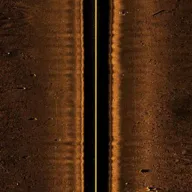
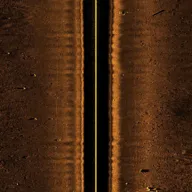
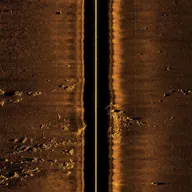
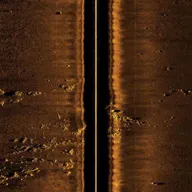
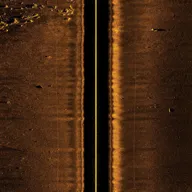
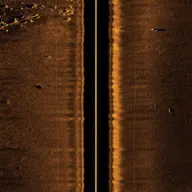
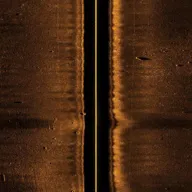
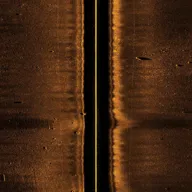
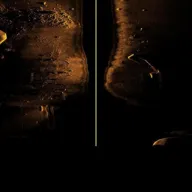
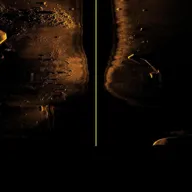
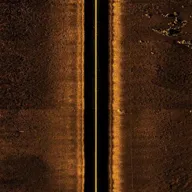
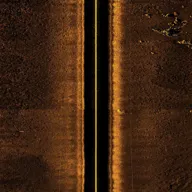
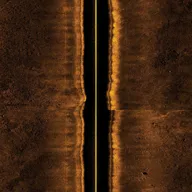
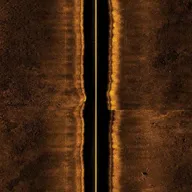
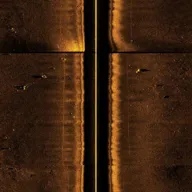
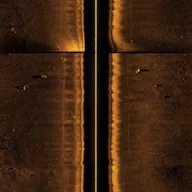
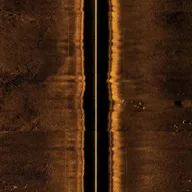
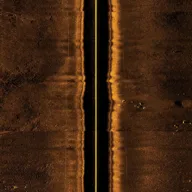
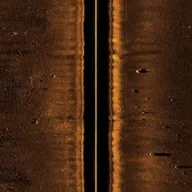
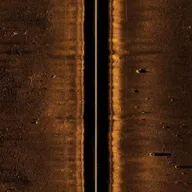
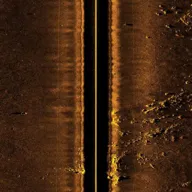
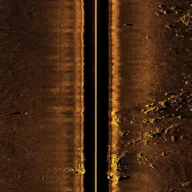
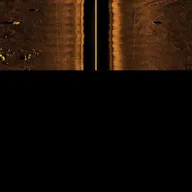
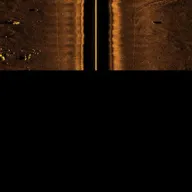
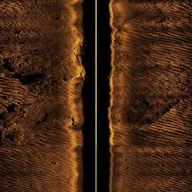
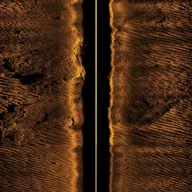
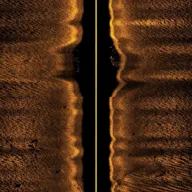
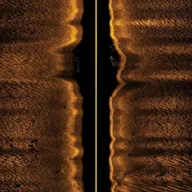
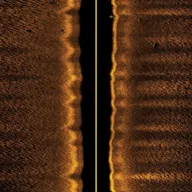
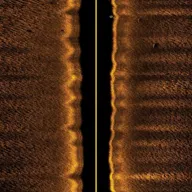
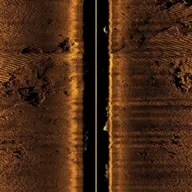
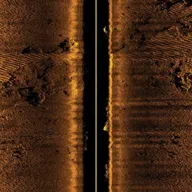
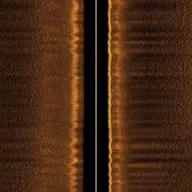
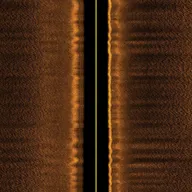
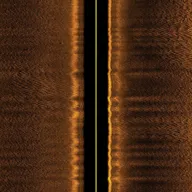
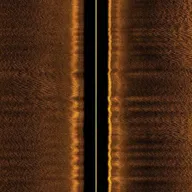
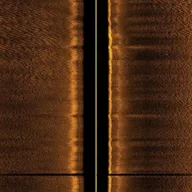
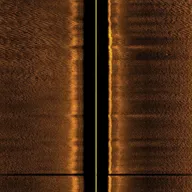
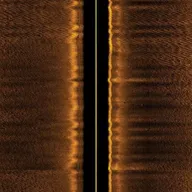
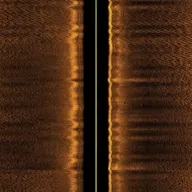
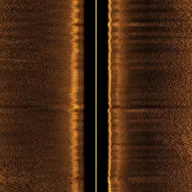
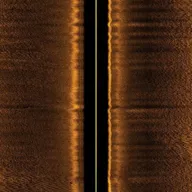
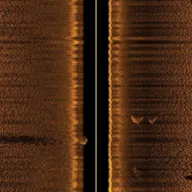
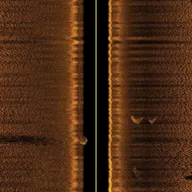
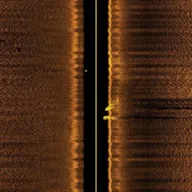
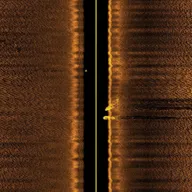
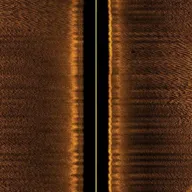
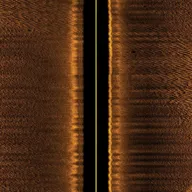
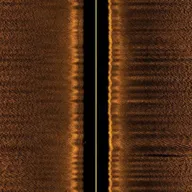
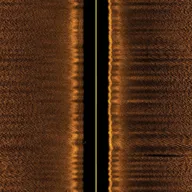
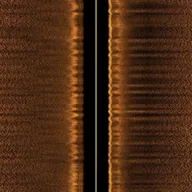
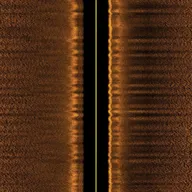
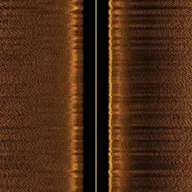
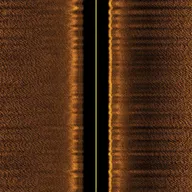
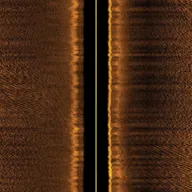
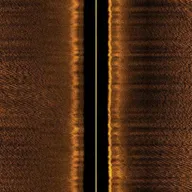

In [8]:
show(clean.to_html())

In [9]:
show(drift.to_html())

<iframe srcdoc="<!doctype html>
<html lang="en">
<head>
<meta charset="utf-8">
<meta name="viewport" content="width=device-width, initial-scale=1">
<title>Shift — drift</title>
<style>:root { color-scheme: light dark;
 --bg: #ffffff; --card: #ffffff; --soft: #f6f8fa; --ink: #111827; --muted: #6b7280; --rule: #e5e7eb;
 --link: #1d4ed8; --ok: #16a34a; --info: #2563eb; --warning: #d97706; --mark: #dc2626;
 --s0: #2563eb; --s1: #d97706; --s2: #7c3aed; --s3: #16a34a;
 --tag: #eef2ff; --tag-ink: #1e1b4b;
}
@media (prefers-color-scheme: dark) { :root {
 --bg: #0f1115; --card: #171a21; --soft: #1d212a; --ink: #e5e7eb; --muted: #9ca3af; --rule: #2a2f3a;
 --link: #93c5fd; --ok: #22c55e; --info: #60a5fa; --warning: #f59e0b; --mark: #f87171;
 --s0: #60a5fa; --s1: #f59e0b; --s2: #a78bfa; --s3: #22c55e;
 --tag: #232a3d; --tag-ink: #c7d2fe;
} }
body { margin: 0; color: var(--ink); background: var(--bg);
 font: 15px/1.5 system-ui, -apple-system, "Segoe UI", Roboto, "Helvetica Neue", Arial, sans-serif; }
main { max-width: 72rem; margin: 0 auto; padding: 1.5rem; }
a { color: var(--link); }
h1, h2, h3, h4 { margin: 1.25rem 0 0.5rem; line-height: 1.25; }
h1 { font-size: 1.6rem; } h2 { font-size: 1.2rem; } h3 { font-size: 1.05rem; } h4 { font-size: 0.95rem; }
nav.contents { border: 1px solid var(--rule); border-radius: 7px; padding: 0.25rem 1rem; margin-bottom: 1.5rem; }
nav.contents h2 { font-size: 1rem; margin: 0.5rem 0; }
.controls { display: flex; justify-content: flex-end; gap: 0.5rem; margin-bottom: 0.5rem; }
.controls button { font: inherit; font-size: 0.8rem; padding: 0.2rem 0.7rem; cursor: pointer;
 color: var(--ink); background: var(--soft); border: 1px solid var(--rule); border-radius: 4px; }
.report { margin-bottom: 2.5rem; }
.report-head { display: flex; align-items: baseline; gap: 0.75rem; flex-wrap: wrap;
 border-bottom: 2px solid var(--ink); padding-bottom: 0.3rem; }
.report-head h1 { margin: 0; }
dl.fields.provenance { display: grid; grid-template-columns: max-content 1fr; gap: 0.15rem 1rem;
 margin: 0.6rem 0 1.2rem; padding: 0.5rem 0.8rem; background: var(--soft); border-radius: 6px;
 color: var(--muted); font-size: 0.85rem; }
dl.provenance dt { font-weight: 600; color: var(--ink); }
dl.provenance dd { margin: 0; overflow-wrap: anywhere; }
section.section > h2 { border-bottom: 1px solid var(--rule); padding-bottom: 0.2rem; }
details.card, details.panel { background: var(--card); border: 1px solid var(--rule);
 border-left: 4px solid var(--info); border-radius: 7px; padding: 0.3rem 1rem 0.6rem; margin: 0.9rem 0; }
details.card.ok { border-left-color: var(--ok); } details.card.warning { border-left-color: var(--warning); }
details.panel { border-left-color: var(--rule); margin-top: 1.5rem; }
:is(details.card, details.panel) > summary { cursor: pointer; list-style: none; }
:is(details.card, details.panel) > summary::-webkit-details-marker { display: none; }
:is(details.card, details.panel) > summary h2 { display: inline; font-size: 1.1rem; margin: 0; }
:is(details.card, details.panel) > summary::before { content: "▸"; color: var(--muted); margin-right: 0.4rem; }
:is(details.card, details.panel)[open] > summary::before { content: "▾"; }
.brief { font-weight: normal; color: var(--muted); margin-left: 0.5rem; }
.badge { font-size: 0.72rem; font-weight: 700; letter-spacing: 0.02em; border-radius: 1rem; padding: 0.05rem 0.55rem;
 margin-left: 0.5rem; color: #fff; background: var(--info); vertical-align: middle; }
.badge.ok { background: var(--ok); } .badge.warning { background: var(--warning); }
.badge.failed { background: var(--mark); }
code, pre { font-family: ui-monospace, SFMono-Regular, Menlo, Consolas, "DejaVu Sans Mono", monospace; }
code { font-size: 0.9em; background: var(--soft); padding: 0 0.2em; border-radius: 3px; }
pre { background: var(--soft); padding: 0.75rem; overflow-x: auto; font-size: 0.85rem; }
pre code { background: none; padding: 0; }
table { border-collapse: collapse; margin: 0.5rem 0; font-size: 0.85rem; font-va

In [10]:
show(drift.to_html(detailed=False))

<iframe srcdoc="<!doctype html>
<html lang="en">
<head>
<meta charset="utf-8">
<meta name="viewport" content="width=device-width, initial-scale=1">
<title>Shift — drift</title>
<style>:root { color-scheme: light dark;
 --bg: #ffffff; --card: #ffffff; --soft: #f6f8fa; --ink: #111827; --muted: #6b7280; --rule: #e5e7eb;
 --link: #1d4ed8; --ok: #16a34a; --info: #2563eb; --warning: #d97706; --mark: #dc2626;
 --s0: #2563eb; --s1: #d97706; --s2: #7c3aed; --s3: #16a34a;
 --tag: #eef2ff; --tag-ink: #1e1b4b;
}
@media (prefers-color-scheme: dark) { :root {
 --bg: #0f1115; --card: #171a21; --soft: #1d212a; --ink: #e5e7eb; --muted: #9ca3af; --rule: #2a2f3a;
 --link: #93c5fd; --ok: #22c55e; --info: #60a5fa; --warning: #f59e0b; --mark: #f87171;
 --s0: #60a5fa; --s1: #f59e0b; --s2: #a78bfa; --s3: #22c55e;
 --tag: #232a3d; --tag-ink: #c7d2fe;
} }
body { margin: 0; color: var(--ink); background: var(--bg);
 font: 15px/1.5 system-ui, -apple-system, "Segoe UI", Roboto, "Helvetica Neue", Arial, sans-serif; }
main { max-width: 72rem; margin: 0 auto; padding: 1.5rem; }
a { color: var(--link); }
h1, h2, h3, h4 { margin: 1.25rem 0 0.5rem; line-height: 1.25; }
h1 { font-size: 1.6rem; } h2 { font-size: 1.2rem; } h3 { font-size: 1.05rem; } h4 { font-size: 0.95rem; }
nav.contents { border: 1px solid var(--rule); border-radius: 7px; padding: 0.25rem 1rem; margin-bottom: 1.5rem; }
nav.contents h2 { font-size: 1rem; margin: 0.5rem 0; }
.controls { display: flex; justify-content: flex-end; gap: 0.5rem; margin-bottom: 0.5rem; }
.controls button { font: inherit; font-size: 0.8rem; padding: 0.2rem 0.7rem; cursor: pointer;
 color: var(--ink); background: var(--soft); border: 1px solid var(--rule); border-radius: 4px; }
.report { margin-bottom: 2.5rem; }
.report-head { display: flex; align-items: baseline; gap: 0.75rem; flex-wrap: wrap;
 border-bottom: 2px solid var(--ink); padding-bottom: 0.3rem; }
.report-head h1 { margin: 0; }
dl.fields.provenance { display: grid; grid-template-columns: max-content 1fr; gap: 0.15rem 1rem;
 margin: 0.6rem 0 1.2rem; padding: 0.5rem 0.8rem; background: var(--soft); border-radius: 6px;
 color: var(--muted); font-size: 0.85rem; }
dl.provenance dt { font-weight: 600; color: var(--ink); }
dl.provenance dd { margin: 0; overflow-wrap: anywhere; }
section.section > h2 { border-bottom: 1px solid var(--rule); padding-bottom: 0.2rem; }
details.card, details.panel { background: var(--card); border: 1px solid var(--rule);
 border-left: 4px solid var(--info); border-radius: 7px; padding: 0.3rem 1rem 0.6rem; margin: 0.9rem 0; }
details.card.ok { border-left-color: var(--ok); } details.card.warning { border-left-color: var(--warning); }
details.panel { border-left-color: var(--rule); margin-top: 1.5rem; }
:is(details.card, details.panel) > summary { cursor: pointer; list-style: none; }
:is(details.card, details.panel) > summary::-webkit-details-marker { display: none; }
:is(details.card, details.panel) > summary h2 { display: inline; font-size: 1.1rem; margin: 0; }
:is(details.card, details.panel) > summary::before { content: "▸"; color: var(--muted); margin-right: 0.4rem; }
:is(details.card, details.panel)[open] > summary::before { content: "▾"; }
.brief { font-weight: normal; color: var(--muted); margin-left: 0.5rem; }
.badge { font-size: 0.72rem; font-weight: 700; letter-spacing: 0.02em; border-radius: 1rem; padding: 0.05rem 0.55rem;
 margin-left: 0.5rem; color: #fff; background: var(--info); vertical-align: middle; }
.badge.ok { background: var(--ok); } .badge.warning { background: var(--warning); }
.badge.failed { background: var(--mark); }
code, pre { font-family: ui-monospace, SFMono-Regular, Menlo, Consolas, "DejaVu Sans Mono", monospace; }
code { font-size: 0.9em; background: var(--soft); padding: 0 0.2em; border-radius: 3px; }
pre { background: var(--soft); padding: 0.75rem; overflow-x: auto; font-size: 0.85rem; }
pre code { background: none; padding: 0; }
table { border-collapse: collapse; margin: 0.5rem 0; font-size: 0.85rem; font-va